# NLP Project Task 2

## Setup

In [ ]:
REPO_URL     = "https://github.com/nailasalmayusroini/NLP-Project-Task1.git"
PROJECT_DIR  = "/content/drive/MyDrive/NLP-Project-Task1"

VAL_START    = "2025-01-01"
NEWS_FILE    = "data/processed/articles_for_features.csv"
COLUMN_MAP   = {"date": "date", "title": "title", "article_text": "body",
                "EventRootCode": "cameo_root", "GoldsteinScale": "gdelt_goldstein",
                "AvgTone": "gdelt_tone", "n_sources_merged": "gdelt_mentions"}

N_COMPONENTS = 30
MIN_DF       = 5

In [ ]:
# Connect Google Drive, copy the GitHub repo into Drive (first time only), install VADER
import os
from google.colab import drive
drive.mount("/content/drive")

if not os.path.exists(PROJECT_DIR):
    !git clone {REPO_URL} "{PROJECT_DIR}"
else:
    print("Project folder already in Drive. Keeping your files as they are.")

os.chdir(PROJECT_DIR)
for folder in ["src/features", "data/external", "data/processed", "models", "notebook/figures"]:
    os.makedirs(folder, exist_ok=True)

!pip install -q vaderSentiment
print("\nWorking in:", os.getcwd())
!ls

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project folder already in Drive. Keeping your files as they are.

Working in: /content/drive/MyDrive/NLP-Project-Task1
data  jisdor_cleaned.xlsx  models  notebook  README.md	src


## Feature

In [ ]:
%%writefile src/features/__init__.py
# Makes src/features a Python package.

Overwriting src/features/__init__.py


In [ ]:
%%writefile src/features/lexicon.py
import re
from collections import Counter

import pandas as pd

LM_CATEGORIES = ["Negative", "Positive", "Uncertainty", "Litigious"]
_TOKEN_RE = re.compile(r"[a-z]+")


# VADER
def vader_title_scores(titles: pd.Series) -> pd.Series:
    #Return the VADER compound score for every title
    from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

    analyzer = SentimentIntensityAnalyzer()
    return titles.fillna("").astype(str).map(
        lambda t: analyzer.polarity_scores(t)["compound"]
    )


# Loughran-McDonald
def load_lm_dictionary(csv_path: str) -> dict:
    lm = pd.read_csv(csv_path)
    lm["Word"] = lm["Word"].astype(str).str.lower()
    return {cat: set(lm.loc[lm[cat] > 0, "Word"]) for cat in LM_CATEGORIES}


def lm_body_scores(bodies: pd.Series, lm_dict: dict) -> pd.DataFrame:
    rows = []
    for text in bodies.fillna("").astype(str):
        tokens = _TOKEN_RE.findall(text.lower())
        counts = Counter(tokens)
        n_words = max(len(tokens), 1)
        row, raw = {}, {}
        for cat, words in lm_dict.items():
            hits = sum(c for w, c in counts.items() if w in words)
            raw[cat] = hits
            row[f"body_lm_{cat.lower()}"] = hits / n_words
        row["body_lm_net"] = (raw["Positive"] - raw["Negative"]) / (
            raw["Positive"] + raw["Negative"] + 1
        )
        row["body_word_count"] = len(tokens)
        rows.append(row)
    return pd.DataFrame(rows, index=bodies.index)

Overwriting src/features/lexicon.py


In [ ]:
%%writefile src/features/entities.py
import re

import pandas as pd

ENTITY_KEYWORDS = {
    # actors
    "us": ["united states", "u.s.", "washington", "white house", "biden",
           "trump", "american"],
    "fed": ["federal reserve", "the fed", "fomc", "powell", "rate hike",
            "rate cut"],
    "china": ["china", "chinese", "beijing", "xi jinping"],
    "indonesia": ["indonesia", "indonesian", "jakarta", "bank indonesia",
                  "rupiah", "prabowo", "jokowi"],
    "russia": ["russia", "russian", "moscow", "kremlin", "putin"],
    "ukraine": ["ukraine", "ukrainian", "kyiv", "zelensky"],
    "middle_east": ["israel", "iran", "gaza", "saudi", "middle east",
                    "houthi", "red sea"],
    # themes
    "sanctions": ["sanction", "embargo", "export control"],
    "tariffs": ["tariff", "trade war", "import duty", "import duties"],
    "conflict": ["war", "attack", "missile", "invasion", "military",
                 "troops", "airstrike"],
    "election": ["election", "ballot", "vote"],
    "oil": ["oil", "crude", "opec", "brent"],
    "inflation": ["inflation", "consumer prices", "cpi"],
}


def _compile(words):
    alt = "|".join(re.escape(w) for w in words)
    return re.compile(rf"(?<![a-z])(?:{alt})s?(?![a-z])")


_PATTERNS = {name: _compile(words) for name, words in ENTITY_KEYWORDS.items()}

_US_CAPS = re.compile(r"(?<![A-Za-z])US(?![A-Za-z])")


def entity_flags(titles: pd.Series, bodies: pd.Series) -> pd.DataFrame:
    """Return one 0/1 column per keyword group, named ent_<group>."""
    raw = titles.fillna("").astype(str) + " " + bodies.fillna("").astype(str)
    text = raw.str.lower()
    out = {f"ent_{name}": text.str.contains(pat).astype(int)
           for name, pat in _PATTERNS.items()}
    out["ent_us"] = (out["ent_us"] | raw.str.contains(_US_CAPS)).astype(int)
    return pd.DataFrame(out, index=titles.index)

Overwriting src/features/entities.py


In [ ]:
%%writefile src/features/tfidf_svd.py
import joblib
import pandas as pd
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS, TfidfVectorizer

# Website text left inside scraped articles (paywall, ad-blocker and audio-player notices)
BOILERPLATE_WORDS = {"browser", "javascript", "blockers", "blocker", "disable", "disabled",
                     "enable", "settings", "proceed", "subscribers", "subscriber", "subscribe",
                     "log", "login", "trinity", "audio", "cookies", "cookie", "ad", "ads",
                     "updated", "edt", "pm", "sep", "click",
                     "extension", "extensions", "couldn", "connection", "load", "loading",
                     "network", "valid", "player", "account"}
STOP_WORDS = list(ENGLISH_STOP_WORDS | BOILERPLATE_WORDS)


def fit_tfidf_svd(train_bodies: pd.Series, n_components: int = 30,
                  min_df: int = 5, max_features: int = 20000,
                  random_state: int = 42):

    vectorizer = TfidfVectorizer(
        lowercase=True,
        token_pattern=r"(?u)\b[a-zA-Z]{2,}\b",   # only real words: drops numbers and codes like "e96"
        stop_words=STOP_WORDS,
        min_df=min_df,        # ignore words in fewer than min_df articles
        max_df=0.8,           # ignore words in more than 80% of articles
        max_features=max_features,
        sublinear_tf=True,    # dampen very repeated words
    )
    X = vectorizer.fit_transform(train_bodies.fillna("").astype(str))
    n_components = min(n_components, X.shape[1] - 1)
    svd = TruncatedSVD(n_components=n_components, random_state=random_state)
    svd.fit(X)
    return vectorizer, svd


def transform_tfidf_svd(bodies: pd.Series, vectorizer, svd) -> pd.DataFrame:

    X = vectorizer.transform(bodies.fillna("").astype(str))
    Z = svd.transform(X)
    cols = [f"body_svd_{i}" for i in range(Z.shape[1])]
    return pd.DataFrame(Z, columns=cols, index=bodies.index)


def top_terms_per_component(vectorizer, svd, n_terms: int = 10) -> pd.DataFrame:

    terms = vectorizer.get_feature_names_out()
    rows = []
    for i, comp in enumerate(svd.components_):
        top = comp.argsort()[::-1][:n_terms]
        rows.append({"component": f"body_svd_{i}",
                     "top_terms": ", ".join(terms[j] for j in top)})
    return pd.DataFrame(rows)


def save(vectorizer, svd, path: str):
    joblib.dump({"vectorizer": vectorizer, "svd": svd}, path)


def load(path: str):
    obj = joblib.load(path)
    return obj["vectorizer"], obj["svd"]

Overwriting src/features/tfidf_svd.py


In [ ]:
%%writefile src/features/aggregate.py
import pandas as pd

NEG_THRESHOLD = -0.05


def aggregate_daily(df: pd.DataFrame, key: str = "trade_date") -> pd.DataFrame:
    df = df.copy()


    if "title_vader" in df:
        df["_title_is_neg"] = (df["title_vader"] < NEG_THRESHOLD).astype(int)
    if {"gdelt_tone", "gdelt_mentions"} <= set(df.columns):
        w = df["gdelt_mentions"].clip(lower=1)
        df["_tone_x_w"] = df["gdelt_tone"] * w
        df["_w"] = w

    g = df.groupby(key)
    out = pd.DataFrame({"news_count": g.size()})

    if "title_vader" in df:
        out["title_vader_mean"] = g["title_vader"].mean()
        out["title_vader_min"] = g["title_vader"].min()
        out["title_vader_std"] = g["title_vader"].std().fillna(0)
        out["title_neg_share"] = g["_title_is_neg"].mean()


    mean_cols = [c for c in df.columns
                 if c.startswith(("body_lm_", "body_svd_", "ent_", "gdelt_cameo_"))]
    if mean_cols:
        means = g[mean_cols].mean()
        means.columns = [c if c.startswith("body_") else f"{c}_share"
                         for c in mean_cols]
        out = out.join(means)

    if "gdelt_goldstein" in df:
        out["gdelt_goldstein_mean"] = g["gdelt_goldstein"].mean()
        out["gdelt_goldstein_min"] = g["gdelt_goldstein"].min()
    if "_w" in df:
        out["gdelt_tone_wmean"] = g["_tone_x_w"].sum() / g["_w"].sum()
        out["gdelt_mentions_sum"] = g["gdelt_mentions"].sum()

    return out.reset_index()

Overwriting src/features/aggregate.py


In [ ]:
%%writefile src/features/build_features.py
import argparse
import json
import re
from pathlib import Path

import pandas as pd

from . import tfidf_svd
from .aggregate import aggregate_daily
from .entities import entity_flags
from .lexicon import lm_body_scores, load_lm_dictionary, vader_title_scores


COLUMN_CANDIDATES = {
    "date": ["date", "published_date", "publish_date", "pub_date",
             "published_at", "datetime", "timestamp", "sqldate", "dateadded"],
    "title": ["title", "headline", "article_title", "news_title"],
    "body": ["body", "text", "content", "full_text", "article_text",
             "clean_text", "cleaned_text", "article", "news_text"],
    "cameo_root": ["eventrootcode", "event_root_code", "cameo_root",
                   "root_code", "cameo"],
    "gdelt_goldstein": ["goldsteinscale", "goldstein_scale", "goldstein"],
    "gdelt_tone": ["avgtone", "avg_tone", "tone"],
    "gdelt_mentions": ["nummentions", "num_mentions", "mentions"],
}
REQUIRED = ["date", "title", "body"]


def _norm(name: str) -> str:
    return re.sub(r"[^a-z0-9]", "", str(name).lower())


def guess_column_map(columns) -> dict:
    """Return {your_column_name: pipeline_name} for every column it recognises."""
    lookup = {_norm(c): c for c in columns}
    mapping = {}
    for target, candidates in COLUMN_CANDIDATES.items():
        for cand in candidates:
            if _norm(cand) in lookup and lookup[_norm(cand)] not in mapping:
                mapping[lookup[_norm(cand)]] = target
                break
    return mapping


def read_table(path) -> pd.DataFrame:
    path = Path(path)
    if path.suffix.lower() in (".xlsx", ".xls"):
        return pd.read_excel(path)
    return pd.read_csv(path)


def _parse_dates(s: pd.Series) -> pd.Series:
    """Handle YYYY-MM-DD strings, timestamps, and GDELT integer dates."""
    if pd.api.types.is_numeric_dtype(s):

        return pd.to_datetime(s.astype("Int64").astype(str).str[:8],
                              format="%Y%m%d", errors="coerce")
    d = pd.to_datetime(s, errors="coerce", format="mixed")
    if getattr(d.dt, "tz", None) is not None:
        d = d.dt.tz_localize(None)
    return d.dt.normalize()


def build(articles, lm, val_start, column_map=None, n_components=30,
          min_df=5, out_dir="data/processed", model_dir="models"):
    """Run the whole feature pipeline and save the outputs. Returns the
    article-level feature table."""
    out_dir, model_dir = Path(out_dir), Path(model_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    model_dir.mkdir(parents=True, exist_ok=True)

    # 1. load Task 1 output
    df = read_table(articles)
    if column_map is None:
        column_map = guess_column_map(df.columns)
    print("Column mapping used (your column -> pipeline name):")
    for k, v in column_map.items():
        print(f"   {k!r:>28} -> {v}")
    df = df.rename(columns={k: v for k, v in column_map.items() if k in df})
    missing = [c for c in REQUIRED if c not in df]
    if missing:
        raise KeyError(f"Could not find columns for {missing}. Your columns "
                       f"are {list(df.columns)}. Set COLUMN_MAP by hand.")

    df["date"] = _parse_dates(df["date"])
    if "trade_date" in df:
        df["trade_date"] = pd.to_datetime(df["trade_date"])
    bad = df["date"].isna().sum()
    if bad:
        print(f"WARNING: dropped {bad} rows with unreadable dates")
        df = df.dropna(subset=["date"])
    for col in ["gdelt_goldstein", "gdelt_tone", "gdelt_mentions"]:
        if col in df:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    df = df.sort_values("date").reset_index(drop=True)
    if "article_id" not in df:
        df.insert(0, "article_id", range(len(df)))
    print(f"Loaded {len(df):,} articles, {df['date'].min().date()} "
          f"to {df['date'].max().date()}")

    # 2. VADER on titles
    df["title_vader"] = vader_title_scores(df["title"])

    # 3. Loughran-McDonald on bodies
    df = df.join(lm_body_scores(df["body"], load_lm_dictionary(lm)))

    # 4. entity / theme keyword flags
    df = df.join(entity_flags(df["title"], df["body"]))

    # 5. GDELT CAMEO root code -> one 0/1 column per code
    if "cameo_root" in df:
        codes = (pd.to_numeric(df["cameo_root"], errors="coerce")
                 .astype("Int64").astype(str).str.zfill(2))
        df = df.join(pd.get_dummies(codes, prefix="gdelt_cameo").astype(int))
        df = df.drop(columns=[c for c in df if c == "gdelt_cameo_<NA>"])

    # 6. TF-IDF + SVD, fitted on TRAIN period only
    split_col = "trade_date" if "trade_date" in df else "date"
    train_mask = df[split_col] < pd.Timestamp(val_start)
    print(f"Fitting TF-IDF/SVD on {train_mask.sum():,} training articles "
          f"({split_col} before {val_start})")
    vec, svd = tfidf_svd.fit_tfidf_svd(df.loc[train_mask, "body"],
                                       n_components=n_components,
                                       min_df=min_df)
    df = df.join(tfidf_svd.transform_tfidf_svd(df["body"], vec, svd))
    tfidf_svd.save(vec, svd, model_dir / "tfidf_svd.joblib")
    tfidf_svd.top_terms_per_component(vec, svd).to_csv(
        out_dir / "svd_top_terms.csv", index=False)

    # 7. save
    feature_cols = [c for c in df.columns
                    if c.startswith(("title_", "body_", "ent_", "gdelt_"))]
    keep = (["article_id", "date"]
            + (["trade_date"] if "trade_date" in df else [])
            + ["title"] + feature_cols)
    df[keep].to_csv(out_dir / "article_features.csv", index=False)
    aggregate_daily(df[keep], key="date").to_csv(
        out_dir / "daily_preview.csv", index=False)
    print(f"Saved {len(feature_cols)} feature columns to {out_dir}/ "
          f"and the TF-IDF/SVD model to {model_dir}/")
    return df[keep]


def main():
    p = argparse.ArgumentParser()
    p.add_argument("--articles", required=True)
    p.add_argument("--lm", required=True, help="LM Master Dictionary CSV")
    p.add_argument("--val-start", required=True,
                   help="first date of the validation period (from Person 3)")
    p.add_argument("--column-map", default=None,
                   help='JSON, e.g. \'{"content": "body"}\'; guessed if omitted')
    p.add_argument("--n-components", type=int, default=30)
    p.add_argument("--min-df", type=int, default=5)
    p.add_argument("--out-dir", default="data/processed")
    p.add_argument("--model-dir", default="models")
    a = p.parse_args()
    build(a.articles, a.lm, a.val_start,
          column_map=json.loads(a.column_map) if a.column_map else None,
          n_components=a.n_components, min_df=a.min_df,
          out_dir=a.out_dir, model_dir=a.model_dir)


if __name__ == "__main__":
    main()

Overwriting src/features/build_features.py


## Find Input Files

In [ ]:
import sys
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
for m in [m for m in list(sys.modules) if m == "src" or m.startswith("src.")]:
    del sys.modules[m]
from src.features.build_features import build, guess_column_map, read_table
print("Feature code loaded.")

Feature code loaded.


In [ ]:
import re
import pandas as pd

news = pd.concat([pd.read_csv(f"data/processed/articles_deduped_{y}.csv")
                  for y in range(2021, 2027)], ignore_index=True)
before = len(news)
news = news.drop_duplicates(subset="GLOBALEVENTID").reset_index(drop=True)
# Apply the Task 1 cap: at most 100 articles per week (only 2021 exceeded it)
news["week"] = pd.to_datetime(news["date"]).dt.to_period("W")
news = (news.groupby("week", group_keys=False)
            .apply(lambda g: g.sample(min(len(g), 100), random_state=42))
            .drop(columns="week").reset_index(drop=True))
print(f"After the 100-per-week cap: {len(news):,} articles")

def first_sentence(text):
    text = re.sub(r"\s+", " ", str(text)).strip()
    return re.split(r"(?<=[.!?])\s+", text, maxsplit=1)[0][:300]

def url_words(url):
    last = str(url).split("?")[0].rstrip("/").split("/")[-1]
    last = re.sub(r"\.(html?|php|aspx?)$", "", last)
    return " ".join(w for w in re.split(r"[-_]+", last) if w.isalpha())

news["title_from_text"] = news["article_text"].map(first_sentence)
news["title_from_url"] = news["SOURCEURL"].map(url_words)
pd.set_option("display.max_colwidth", 120)
news[["title_from_text", "title_from_url"]].sample(10, random_state=0)

/tmp/ipykernel_6049/3561491412.py:12: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(min(len(g), 100), random_state=42))


After the 100-per-week cap: 4,869 articles


,title_from_text,title_from_url
1891,Crime boss Liam Byrne says extradition to UK would put him at risk of 'inhumane and degrading treatment' The extraor...,crime boss liam byrne says
4688,By BILL BARROW ATLANTA (AP) — President Donald Trump has tried many ways to tighten his grip on U.S.,trump voting midterm elections
3861,Getting your Trinity Audio player ready...,federal task force launches in memphis makes nine arrests on first day
4381,Lincoln County man accused in shots fired incident apprehended by W.Va.,troopers search for man accused of wanton endangerment in lincoln county
1654,"Two months after being indicted on a burglary charge in Bell County, a man was indicted in Coryell County on a felon...",article
4358,Michelle Obama leaves people wondering with her latest move Michelle Obama is once again the topic of discussion pos...,michelle obama leaves people wondering with her latest move
1564,EXCLUSIVE: Prince Harry 'clearly enjoyed Coronation' but 'sadness' that Archie and Lilibet missed out The Duke of Su...,prince harry clearly enjoyed coronation
3295,"Суд вынес приговоры заключенным-бунтовщикам из Ангарска 12 заключенных, виновных в массовых беспорядках в колонии в ...",
1757,Delta Air Lines enfrenta demanda millonaria por abuso sexual en vuelo La dama alega que ella y su hija adolescente f...,
728,"Oggi riprendono i negoziati online fra russi e ucraini, ma le relazioni sono rese incandescenti dal decreto di Putin...",ucraina i russi lasciano chernobyl ma fanno ostaggi aut aut di putin sul gas oggi negoziati online


### **Check: which Task 1 file to use**

In [ ]:
allf = pd.read_csv("data/processed/articles_deduped_all_years.csv")
print("Repeated GDELT IDs:", allf["GLOBALEVENTID"].duplicated().sum())
print("Repeated article texts:", allf["article_text"].duplicated().sum())
for y in range(2021, 2027):
    n_all = (pd.to_datetime(allf["date"]).dt.year == y).sum()
    n_year = len(pd.read_csv(f"data/processed/articles_deduped_{y}.csv"))
    print(y, "| all-years file:", n_all, "| yearly file:", n_year)

Repeated GDELT IDs: 1135
Repeated article texts: 1155
2021 | all-years file: 2746 | yearly file: 1654
2022 | all-years file: 873 | yearly file: 832
2023 | all-years file: 775 | yearly file: 768
2024 | all-years file: 877 | yearly file: 926
2025 | all-years file: 1057 | yearly file: 1052
2026 | all-years file: 835 | yearly file: 791


The combined all-years file contained 1,135 repeated GDELT IDs (mostly in 2021: 2,746 articles vs. 1,654 in the yearly file), so it appears to be an outdated version. We therefore build the dataset from the six yearly files instead.

In [ ]:
# Keep English articles only, then pick the best stand-in headline
ENGLISH_WORDS = {"the", "and", "of", "to", "in", "is", "that", "for", "on", "with",
                 "was", "said", "as", "by", "it", "at", "from"}

def is_english(text, threshold=0.08):
    t = str(text)
    letters = re.findall(r"[^\W\d_]", t)
    if len(letters) < 150:                                   # too short to judge
        return False
    if sum(ch.isascii() for ch in letters) / len(letters) < 0.9:
        return False                                         # mostly non-Latin script
    words = re.findall(r"[a-z]+", t.lower())
    return sum(w in ENGLISH_WORDS for w in words) / max(len(words), 1) > threshold

def pick_title(row):
    url_title = row["title_from_url"] if isinstance(row["title_from_url"], str) else ""
    return url_title if len(url_title.split()) >= 4 else row["title_from_text"]

news["is_english"] = news["article_text"].map(is_english)
print(f"English articles: {news['is_english'].sum():,} of {len(news):,}")

news_en = news[news["is_english"]].copy()
news_en["title"] = news_en.apply(pick_title, axis=1)
news_en["article_id"] = news_en["GLOBALEVENTID"]
news_en.to_csv("data/processed/articles_for_features.csv", index=False)
print("Saved data/processed/articles_for_features.csv (English only, URL-based headlines)")

English articles: 3,617 of 4,869
Saved data/processed/articles_for_features.csv (English only, URL-based headlines)


In [ ]:
# Fix article dates using the publication date in the URL (prevents data leakage)
u = news_en["SOURCEURL"].str.extract(r"/(20\d\d)/(\d{1,2})/(\d{1,2})/")
url_date = pd.to_datetime(u[0] + "-" + u[1] + "-" + u[2], errors="coerce")
gap = (url_date - pd.to_datetime(news_en["date"])).dt.days
print(f"Articles with a date in their URL: {gap.notna().sum():,} of {len(news_en):,}")
print(f"Published AFTER their GDELT date: {(gap > 0).sum():,} (more than 7 days: {(gap > 7).sum():,})")

later = gap > 0
news_en.loc[later, "date"] = url_date[later].dt.strftime("%Y-%m-%d")
news_en.to_csv("data/processed/articles_for_features.csv", index=False)
print(f"Moved {later.sum():,} articles to their real publication date and re-saved the file.")

Articles with a date in their URL: 872 of 3,617
Published AFTER their GDELT date: 52 (more than 7 days: 27)
Moved 52 articles to their real publication date and re-saved the file.


In [ ]:
import numpy as np
jis = pd.read_excel("jisdor_cleaned.xlsx", header=4)
trading_days = pd.to_datetime(jis["date_clean"].dropna()).sort_values().unique()
idx = np.searchsorted(trading_days, pd.to_datetime(news_en["date"]).values, side="left")
ok = idx < len(trading_days)
print(f"Dropped {(~ok).sum()} articles dated after the last JISDOR date ({pd.Timestamp(trading_days[-1]).date()})")
news_en = news_en[ok].copy()
news_en["trade_date"] = pd.to_datetime(trading_days[idx[ok]]).strftime("%Y-%m-%d")
news_en.to_csv("data/processed/articles_for_features.csv", index=False)
print(f"Saved {len(news_en):,} articles with trade_date")

Dropped 40 articles dated after the last JISDOR date (2026-09-01)
Saved 3,577 articles with trade_date


In [ ]:
# Find the Task 1 news file: any CSV/Excel file that has a title column AND a text column
import pandas as pd
from pathlib import Path

def columns_of(path):
    try:
        if path.suffix.lower() in (".xlsx", ".xls"):
            return list(pd.read_excel(path, nrows=0).columns)
        return list(pd.read_csv(path, nrows=0).columns)
    except Exception:
        return []

skip = {"processed", "external", ".git", "models"}
candidates = []
for p in sorted(Path(".").rglob("*")):
    if p.suffix.lower() in (".csv", ".xlsx", ".xls") and not (skip & set(p.parts)):
        found = set(guess_column_map(columns_of(p)).values())
        if {"title", "body"} <= found:
            candidates.append(str(p))

print("Files that look like news data:", candidates or "NONE FOUND")
if NEWS_FILE is None:
    if not candidates:
        raise FileNotFoundError(
            "No news file found automatically. Put your Task 1 news CSV in the "
            "project's data/ folder in Drive, or set NEWS_FILE in the Settings cell.")
    NEWS_FILE = candidates[0]
print("Using NEWS_FILE =", NEWS_FILE)

news = read_table(NEWS_FILE)
print(f"{len(news):,} rows. Columns: {list(news.columns)}")
print("Guessed column mapping:", COLUMN_MAP or guess_column_map(news.columns))
news.head(3)

Files that look like news data: NONE FOUND
Using NEWS_FILE = data/processed/articles_for_features.csv
3,577 rows. Columns: ['GLOBALEVENTID', 'SQLDATE', 'Actor1CountryCode', 'Actor2CountryCode', 'EventCode', 'EventRootCode', 'GoldsteinScale', 'AvgTone', 'SOURCEURL', 'date', 'sample_type', 'event_label', 'article_text', 'n_sources_merged', 'title_from_text', 'title_from_url', 'is_english', 'title', 'article_id', 'trade_date']
Guessed column mapping: {'date': 'date', 'title': 'title', 'article_text': 'body', 'EventRootCode': 'cameo_root', 'GoldsteinScale': 'gdelt_goldstein', 'AvgTone': 'gdelt_tone', 'n_sources_merged': 'gdelt_mentions'}


,GLOBALEVENTID,SQLDATE,Actor1CountryCode,Actor2CountryCode,EventCode,EventRootCode,GoldsteinScale,AvgTone,SOURCEURL,date,sample_type,event_label,article_text,n_sources_merged,title_from_text,title_from_url,is_english,title,article_id,trade_date
0,1002586018,20210905,NaN,USA,172,17,-5.0,-4.810997,http://lratvakan.com/news/1014893.html,2021-09-05,regular,NaN,Checking your browser Please wait a few seconds. We are performing an automatic security check. The page will refres...,3,Checking your browser Please wait a few seconds.,NaN,True,Checking your browser Please wait a few seconds.,1002586018,2021-09-06
1,1002146308,20210902,USA,NaN,1724,17,-5.0,-6.666667,https://www.fox5ny.com/news/de-blasio-declares-state-of-emergency-in-nyc,2021-09-02,regular,NaN,"State of Emergency in NYC, NY, NJ due to historic flooding NEW YORK - A State of Emergency was declared in New York,...",1,"State of Emergency in NYC, NY, NJ due to historic flooding NEW YORK - A State of Emergency was declared in New York,...",de blasio declares state of emergency in nyc,True,de blasio declares state of emergency in nyc,1002146308,2021-09-02
2,1002498339,20210904,DEU,NaN,145,14,-7.5,-3.148615,https://artdaily.com/news/139017/Max-Liebermann-s-heirs-compensated-for-Nazi-looted-painting,2021-09-04,regular,NaN,"| | Tell a Friend Dear User, please complete the form below in order to recommend the Artdaily newsletter to someone...",2,"| | Tell a Friend Dear User, please complete the form below in order to recommend the Artdaily newsletter to someone...",Max Liebermann s heirs compensated for Nazi looted painting,True,Max Liebermann s heirs compensated for Nazi looted painting,1002498339,2021-09-06


Listing all project files showed that the Task 1 news data has no title column (only `article_text`), which is why stand-in headlines are created from the article URLs.

In [ ]:
# Find the Loughran-McDonald dictionary in data/external/, or ask you to upload it (first time only)
import shutil

def lm_files():
    out = []
    for p in sorted(Path("data/external").glob("*.csv")):
        cols = set(columns_of(p))
        if {"Word", "Negative", "Positive"} <= cols:
            out.append(p)
    return out

if not lm_files():
    print("Loughran-McDonald dictionary not found.")
    print("Download 'Loughran-McDonald Master Dictionary' (CSV) from the Notre Dame SRAF website,")
    print("then choose it with the button below.")
    from google.colab import files
    for name in files.upload():
        target = Path("data/external") / name
        shutil.move(name, target)
        print("Saved to", target)

assert lm_files(), "The uploaded file is not the LM Master Dictionary CSV (needs Word/Negative/Positive columns)."
LM_FILE = str(lm_files()[0])
print("Using LM_FILE =", LM_FILE)

Using LM_FILE = data/external/Loughran-McDonald_MasterDictionary_1993-2025.csv


## Build Features

In [ ]:
features = build(NEWS_FILE, LM_FILE, VAL_START, column_map=COLUMN_MAP,
                 n_components=N_COMPONENTS, min_df=MIN_DF)
features.head()

Column mapping used (your column -> pipeline name):
                         'date' -> date
                        'title' -> title
                 'article_text' -> body
                'EventRootCode' -> cameo_root
               'GoldsteinScale' -> gdelt_goldstein
                      'AvgTone' -> gdelt_tone
             'n_sources_merged' -> gdelt_mentions
Loaded 3,577 articles, 2021-09-01 to 2026-09-01
Fitting TF-IDF/SVD on 2,185 training articles (trade_date before 2025-01-01)
Saved 63 feature columns to data/processed/ and the TF-IDF/SVD model to models/


,article_id,date,trade_date,title,gdelt_goldstein,gdelt_tone,gdelt_mentions,title_from_text,title_from_url,title_vader,...,body_svd_20,body_svd_21,body_svd_22,body_svd_23,body_svd_24,body_svd_25,body_svd_26,body_svd_27,body_svd_28,body_svd_29
0,1002034510,2021-09-01,2021-09-01,last neilah in telz,-9.0,-1.108609,1,The final accounts of Telz's last Jewish women Open each gray file and you’ll find colorless forms and government re...,last neilah in telz,0.0000,...,-0.032581,0.030422,0.047832,0.028726,0.015598,-0.037612,-0.002391,0.017590,0.029331,0.071003
1,1001957980,2021-09-01,2021-09-01,super tucano jets deployed to battle bandits insurgents,-7.2,-0.946372,1,"News Follow Us on Google September 1, 2021 by The Nation Super Tucano jets deployed to battle bandits, insurgents Si...",super tucano jets deployed to battle bandits insurgents,0.3182,...,-0.075687,0.044390,0.038891,-0.002807,-0.025211,0.021963,0.036390,0.012872,0.041464,-0.081392
2,1002096281,2021-09-01,2021-09-01,Ida damages more than Mississippi homes,-7.0,-5.357143,46,JavaScript is disabled in your browser.,Ida damages more than Mississippi homes,-0.4404,...,0.325099,0.030152,0.004360,-0.123586,0.047949,-0.121796,0.024015,0.082716,0.076663,-0.012388
3,1002111976,2021-09-01,2021-09-01,How the American Revolution played in British drawing rooms,-4.4,-1.248439,1,How the American Revolution played in British drawing rooms Loading...,How the American Revolution played in British drawing rooms,0.3400,...,-0.046053,0.067143,0.063156,0.032483,0.014801,0.020717,-0.006726,0.035146,-0.011710,0.043606
4,1002035382,2021-09-01,2021-09-01,"I grew up in an Ashkenazic home, but as a child I also grimaced over tzimmes.",-5.6,1.057906,1,"I grew up in an Ashkenazic home, but as a child I also grimaced over tzimmes.",what a tzimmes,-0.6124,...,0.014217,-0.019847,-0.051296,0.020915,-0.003260,-0.000473,0.000512,-0.000232,-0.017427,-0.011700


### **Check: locating the news data**

In [ ]:
from pathlib import Path
for p in sorted(Path(".").rglob("*")):
    if ".git" in p.parts or p.is_dir():
        continue
    print(p, f"({p.stat().st_size // 1024} KB)")
    if p.suffix.lower() in (".csv", ".xlsx", ".xls"):
        print("    columns:", columns_of(p))

README.md (0 KB)
data/external/Loughran-McDonald_MasterDictionary_1993-2025.csv (8880 KB)
    columns: ['Word', 'Seq_num', 'Word Count', 'Word Proportion', 'Average Proportion', 'Std Dev', 'Doc Count', 'Negative', 'Positive', 'Uncertainty', 'Litigious', 'Strong_Modal', 'Weak_Modal', 'Constraining', 'Complexity', 'Syllables', 'Source']
data/processed/article_features.csv (3989 KB)
    columns: ['article_id', 'date', 'trade_date', 'title', 'gdelt_goldstein', 'gdelt_tone', 'gdelt_mentions', 'title_from_text', 'title_from_url', 'title_vader', 'body_lm_negative', 'body_lm_positive', 'body_lm_uncertainty', 'body_lm_litigious', 'body_lm_net', 'body_word_count', 'ent_us', 'ent_fed', 'ent_china', 'ent_indonesia', 'ent_russia', 'ent_ukraine', 'ent_middle_east', 'ent_sanctions', 'ent_tariffs', 'ent_conflict', 'ent_election', 'ent_oil', 'ent_inflation', 'gdelt_cameo_10', 'gdelt_cameo_13', 'gdelt_cameo_14', 'gdelt_cameo_15', 'gdelt_cameo_16', 'gdelt_cameo_17', 'gdelt_cameo_18', 'gdelt_cameo_20', 'b

In [ ]:
check_cols = [c for c in ["date", "title", "title_vader", "body_lm_negative",
                          "ent_sanctions", "ent_conflict", "ent_us"] if c in features]
pd.set_option("display.max_colwidth", 90)
features[check_cols].sample(min(10, len(features)), random_state=1)

,date,title,title_vader,body_lm_negative,ent_sanctions,ent_conflict,ent_us
349,2021-12-30,pdea seizes million shabu mandaluyong,0.0000,0.066667,0,0,0
3322,2026-04-27,chinas industrial profit growth quickens even as iran war heightens risks,-0.1280,0.027778,0,1,0
93,2021-09-27,arkansas gov joins state leaders in calling for meeting with biden about border not ju...,0.0000,0.012146,0,0,1
3133,2026-02-01,top trade negotiators take turns visiting us to avert tariff hike,0.0258,0.037351,1,0,1
2567,2025-05-26,china criticises plan to return darwin port to australian ownership,-0.3182,0.018657,0,1,1
487,2022-03-14,"Authorities arrest man on drug-traffic charges Published 8:11 am Monday, March 14, 202...",-0.2500,0.040921,0,0,0
2774,2025-09-03,amid high profile shootings nypd,0.0000,0.006608,0,0,0
3229,2026-03-05,police warned prosecutors times about violent illegal immigrant before he allegedly ki...,-0.9337,0.081137,0,0,1
2209,2025-01-03,ethics report details allegations campaign,0.0000,0.014887,0,0,1
2622,2025-06-17,"On the Russian side, the meeting was attended by Foreign Minister Sergei Lavrov, Deput...",0.0000,0.002339,0,1,0


In [ ]:
pd.read_csv("data/processed/svd_top_terms.csv")

,component,top_terms
0,body_svd_0,"said, police, people, year, state, new, court, according, years, president"
1,body_svd_1,"ukraine, russia, russian, military, ukrainian, war, putin, forces, china, moscow"
2,body_svd_2,"russian, ukraine, russia, ukrainian, police, moscow, putin, forces, military, kyiv"
3,body_svd_3,"trump, court, judge, trial, attorney, prison, president, case, election, guilty"
4,body_svd_4,"china, chinese, beijing, taiwan, foreign, global, kong, hong, united, countries"
5,body_svd_5,"police, trump, israel, biden, election, county, president, gaza, republican, arrested"
6,body_svd_6,"israel, gaza, israeli, hamas, palestinian, iran, british, minister, jewish, netanyahu"
7,body_svd_7,"trump, election, donald, presidential, president, biden, harris, republican, party, ca..."
8,body_svd_8,"israel, israeli, gaza, iran, hamas, air, judge, water, weather, iranian"
9,body_svd_9,"uk, minister, labour, british, mr, prime, said, sunak, london, britain"


## EDA

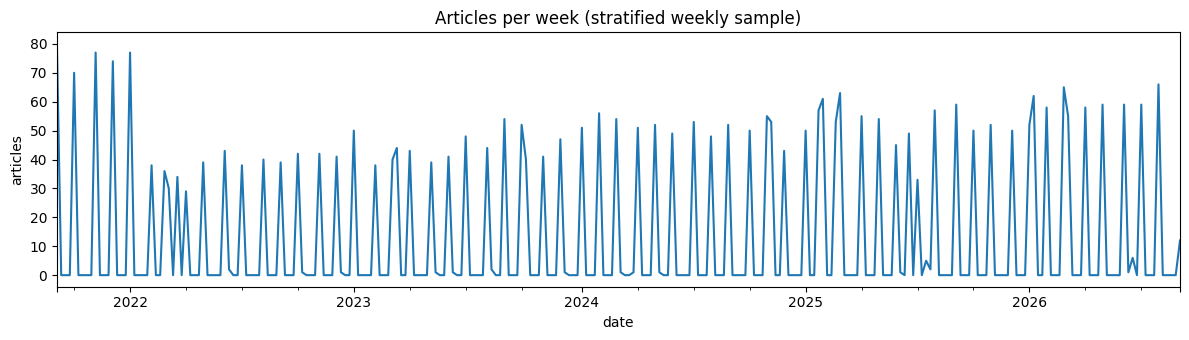

In [ ]:
import matplotlib.pyplot as plt
os.makedirs("notebook/figures", exist_ok=True)
f = features.copy()
f["date"] = pd.to_datetime(f["date"])

def save(name):
    plt.tight_layout()
    plt.savefig(f"notebook/figures/{name}.png", dpi=150)
    plt.show()

# 1. Articles per week: shows the Task 1 stratified sampling pattern (100-article cap per week)
f.set_index("date").resample("W").size().plot(figsize=(12, 3.5), color="tab:blue")
plt.title("Articles per week (stratified weekly sample)")
plt.ylabel("articles")
save("01_articles_per_week")

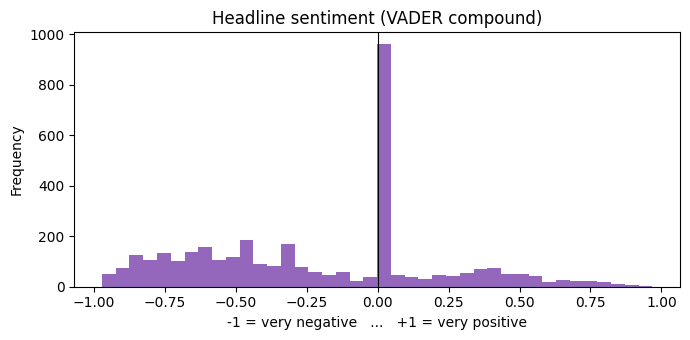

In [ ]:
# 2. Headline sentiment distribution (VADER)
f["title_vader"].plot.hist(bins=40, figsize=(7, 3.5), color="tab:purple")
plt.axvline(0, color="black", lw=0.8)
plt.title("Headline sentiment (VADER compound)")
plt.xlabel("-1 = very negative   ...   +1 = very positive")
save("02_vader_distribution")

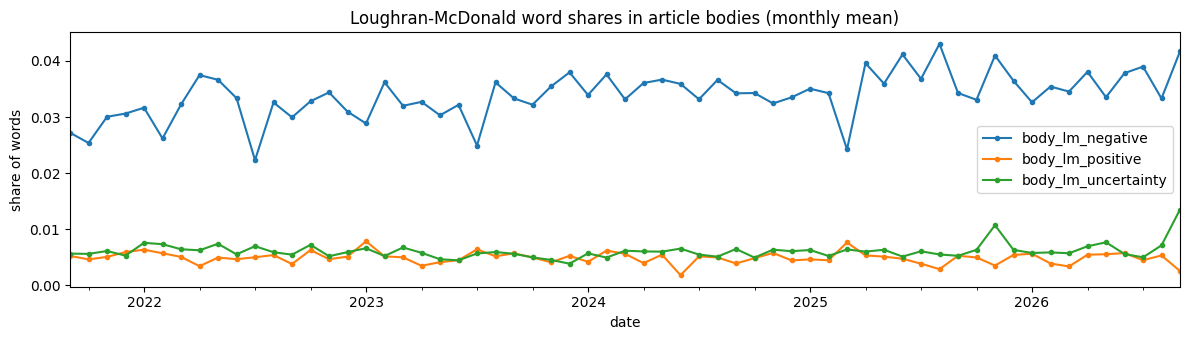

In [ ]:
# 3. Loughran-McDonald financial tone over time (monthly average)
lm_cols = [c for c in ["body_lm_negative", "body_lm_positive", "body_lm_uncertainty"] if c in f]
f.set_index("date")[lm_cols].resample("MS").mean().dropna().plot(figsize=(12, 3.5), marker=".")
plt.title("Loughran-McDonald word shares in article bodies (monthly mean)")
plt.ylabel("share of words")
save("03_lm_over_time")

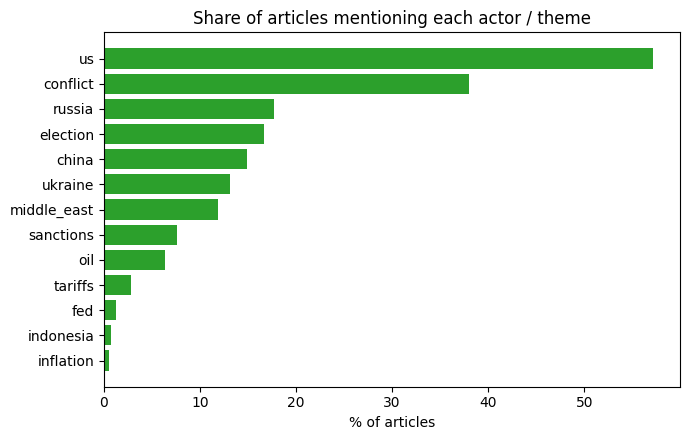

In [ ]:
# 4. How often each actor / theme appears
ent_cols = [c for c in f if c.startswith("ent_")]
shares = f[ent_cols].mean().sort_values() * 100
plt.figure(figsize=(7, 4.5))
plt.barh([c[4:] for c in shares.index], shares.values, color="tab:green")
plt.title("Share of articles mentioning each actor / theme")
plt.xlabel("% of articles")
save("04_entity_shares")

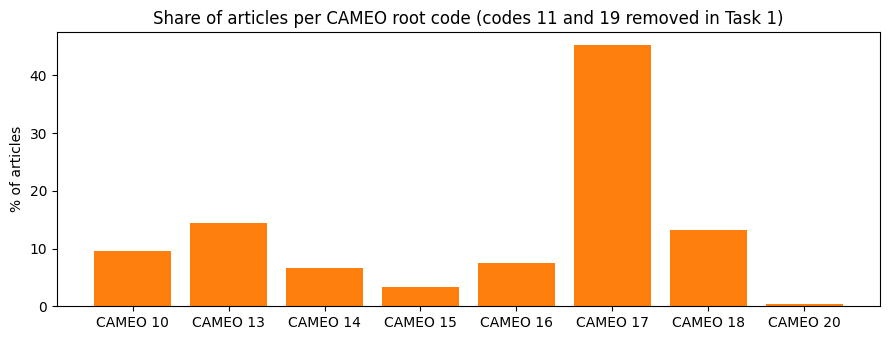

In [ ]:
# 5. GDELT CAMEO event types (only if your data has the CAMEO column)
cameo_cols = [c for c in f if c.startswith("gdelt_cameo_")]
if cameo_cols:
    shares = f[cameo_cols].mean() * 100
    plt.figure(figsize=(9, 3.5))
    plt.bar([c.replace("gdelt_cameo_", "CAMEO ") for c in shares.index], shares.values, color="tab:orange")
    plt.title("Share of articles per CAMEO root code (codes 11 and 19 removed in Task 1)")
    plt.ylabel("% of articles")
    save("05_cameo_shares")
else:
    print("No CAMEO column in the data. Skipping this chart.")

Read 1,202 JISDOR days, 2021-09-01 to 2026-09-01


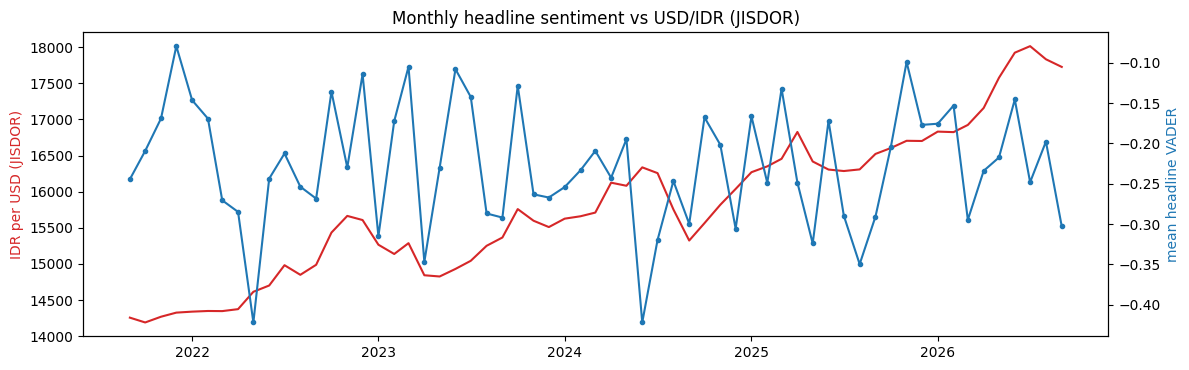

In [ ]:
# 6. Headline sentiment vs the USD/IDR rate (JISDOR, cleaned by Person 2)
jisdor = pd.read_excel("jisdor_cleaned.xlsx", header=4)      # the real table starts on row 5
jisdor = jisdor[["date_clean", "usd_idr"]].dropna()
jisdor["date"] = pd.to_datetime(jisdor["date_clean"])
jisdor["usd_idr"] = pd.to_numeric(jisdor["usd_idr"], errors="coerce")
print(f"Read {len(jisdor):,} JISDOR days, {jisdor['date'].min().date()} to {jisdor['date'].max().date()}")

r = jisdor.set_index("date")["usd_idr"].resample("MS").mean()
s = f.set_index("date")["title_vader"].resample("MS").mean()
fig, ax1 = plt.subplots(figsize=(12, 3.8))
ax1.plot(r.index, r.values, color="tab:red")
ax1.set_ylabel("IDR per USD (JISDOR)", color="tab:red")
ax2 = ax1.twinx()
ax2.plot(s.index, s.values, color="tab:blue", marker=".")
ax2.set_ylabel("mean headline VADER", color="tab:blue")
plt.title("Monthly headline sentiment vs USD/IDR (JISDOR)")
save("06_sentiment_vs_jisdor")

### **Check: JISDOR file layout**

In [ ]:
raw = pd.read_excel("jisdor_cleaned.xlsx", header=None)
display(raw.head(8))

,0,1,2,3
0,NaN,NaN,NaN,NaN
1,NaN,NaN,NaN,NaN
2,Informasi Kurs Jisdor,NaN,Informasi Kurs Jisdor,Informasi Kurs Jisdor
3,NaN,NaN,NaN,NaN
4,Tanggal,date_clean,usd_idr,NaN
5,9/1/2026 12:00:00 AM,2026-09-01,17727,NaN
6,8/31/2026 12:00:00 AM,2026-08-31,17746,NaN
7,8/28/2026 12:00:00 AM,2026-08-28,17703,NaN


The Excel file has title rows above the table and two date columns: `Tanggal` (original, US format M/D/Y) and `date_clean` (cleaned by Person 2, YYYY-MM-DD). The chart uses `date_clean`, since reading `Tanggal` with day-first parsing swapped day and month.